<a href="https://colab.research.google.com/github/uditi-12/CCPS/blob/main/CCPS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Downloading

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# from google.colab import files
# files.upload()

In [ ]:
# !pip install -q kaggle

In [ ]:
# !mkdir -p ~/.kaggle
# !cp kaggle.json ~/.kaggle/

In [ ]:
# cd "/content/drive/MyDrive/Explainable AI _ Research/chest_xray"

In [ ]:
# !pwd

In [ ]:
# !chmod 600 /root/.kaggle/kaggle.json

In [ ]:
# !kaggle datasets download -d paultimothymooney/chest-xray-pneumonia

In [ ]:
# !unzip chest-xray-pneumonia.zip

# Data Loading

In [ ]:
# import required module
from PIL import Image


# get image
filepath = "/content/drive/MyDrive/Explainable AI _ Research/chest_xray/train/NORMAL/IM-0115-0001.jpeg"
img = Image.open(filepath)

# get width and height
width = img.width
height = img.height

# display width and height
print("The height of the image is: ", height)
print("The width of the image is: ", width)
from PIL import Image
from PIL import ImageFilter
#read the image, creating an object
im = Image.open(r"/content/drive/MyDrive/Explainable AI _ Research/chest_xray/train/NORMAL/IM-0115-0001.jpeg")
#show picture
im.show()


The height of the image is:  1858
The width of the image is:  2090


In [ ]:
!pip install shap

In [ ]:
!pip install tf_clahe

In [ ]:
import tf_clahe

/usr/local/lib/python3.10/dist-packages/tensorflow_addons/utils/tfa_eol_msg.py:23: UserWarning: 

TensorFlow Addons (TFA) has ended development and introduction of new features.
TFA has entered a minimal maintenance and release mode until a planned end of life in May 2024.
Please modify downstream libraries to take dependencies from other repositories in our TensorFlow community (e.g. Keras, Keras-CV, and Keras-NLP). 

For more information see: https://github.com/tensorflow/addons/issues/2807 

  warnings.warn(


In [ ]:
def aa_shahe(x):
    img_clahe = tf_clahe.clahe(x)

    # With custom parameters (4x4 tiling and 3.0 clip limit)
    img_clahe = tf_clahe.clahe(x, tile_grid_size=(4, 4), clip_limit=3.0)

    return img_clahe

In [ ]:
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Class weight calculation
from sklearn.utils.class_weight import compute_class_weight

# Keras library
import tensorflow.keras as K
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from keras.preprocessing.image import ImageDataGenerator
from keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from keras import regularizers
from keras.callbacks import ReduceLROnPlateau

# Different CNN Model
from tensorflow.keras.applications import VGG16, ResNet50, InceptionV3, MobileNetV2, DenseNet121

# To chain two different data augmented images for training
from itertools import chain

#  Distributed Computing
import tensorflow as tf
import shap
import pickle
from tensorflow import keras

In [ ]:
image_height = 256
image_width = 256

In [ ]:
def sharpen(im):
  sharpened1 = im.filter(ImageFilter.SHARPEN);
  return sharpened1

In [ ]:
data_generator_3 = ImageDataGenerator (rescale=1./255,
                                      preprocessing_function=aa_shahe)

In [ ]:
data_generator_1 = ImageDataGenerator(
                            rescale=1./255,
                            rotation_range=5,
                            width_shift_range=0.05,
                            height_shift_range=0.05,
                            shear_range=0.05,
                            zoom_range=0.05,
                            brightness_range = [0.95,1.05],
                            horizontal_flip=False,
                            vertical_flip=False,
                            preprocessing_function=aa_shahe,
                            fill_mode='nearest'
                        )

In [ ]:
# train_generator = data_generator_1.flow_from_directory(
#     directory = "/content/drive/MyDrive/Explainable AI _ Research/chest_xray/train/", # images data path / folder in which images are there
#     color_mode = "rgb",
#     target_size = (image_height, image_width), # image height , image width
#     class_mode = "categorical",
#     shuffle = False,  # Idhar change kiya hai :)
#     # batch_size = 49,
#     seed = 42)

In [ ]:
# data_generator_2 = ImageDataGenerator(width_shift_range=0.02,
#                              height_shift_range=0.02,
# #                             horizontal_flip=True,
#                              rotation_range=50,
#                              brightness_range=[0.15,2.0],
#                             #  zoom_range=[5,0.5],
#                             # preprocessing_function=sharpen
#                                       )

In [ ]:
# data_generator_3 = ImageDataGenerator (rescale=1./255,preprocessing_function=AHE)

In [ ]:
# train_generator = train_generator.map(sharpen, num_parallel_calls=tf.data.experimental.AUTOTUNE)

In [ ]:
train_generator = data_generator_1.flow_from_directory(
    directory = "/content/drive/MyDrive/Explainable AI _ Research/chest_xray/train/", # images data path / folder in which images are there
    color_mode = "rgb",
    target_size = (image_height, image_width), # image height , image width
    class_mode = "categorical",
    shuffle = False,  # Idhar change kiya hai :)
    # batch_size = 49,
    seed = 42)

Found 5216 images belonging to 2 classes.


In [ ]:
dict_class = train_generator.class_indices
print('Dictionary: {}'.format(dict_class))
class_names = list(dict_class.keys())  # storing class/breed names in a list
print('Class labels: {}'.format(class_names))

Dictionary: {'NORMAL': 0, 'PNEUMONIA': 1}
Class labels: ['NORMAL', 'PNEUMONIA']


[1. 0.]


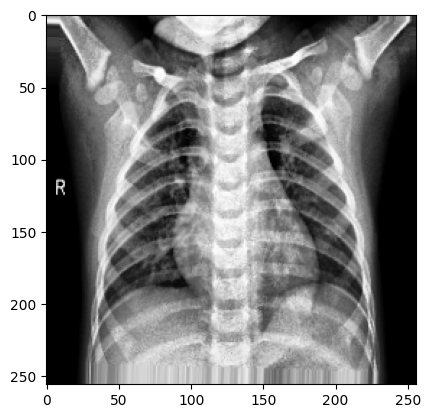

In [ ]:
# train_generator.batches(512)
im = train_generator.next()
#show picture
plt.imshow(im[0][15])
print(im[1][15])

# Test Generator

In [ ]:
test_generator = data_generator_3.flow_from_directory(
    directory = "/content/drive/MyDrive/Explainable AI _ Research/chest_xray/test/", # images data path / folder in which images are there
    color_mode = "rgb",
    target_size = (image_height, image_width), # image height , image width
    class_mode = "categorical",
    shuffle = True,
    # batch_size=317,
    seed = 42)

Found 624 images belonging to 2 classes.


[0. 1.]


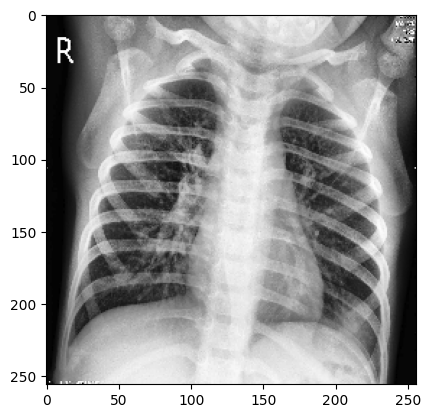

In [ ]:
im = test_generator.next()
#show picture
plt.imshow(im[0][0])
print(im[1][0])


# Local Binary Patterns (LBP)

In [ ]:
# import the necessary packages
from skimage import feature
import numpy as np
class LocalBinaryPatterns:
	def __init__(self, numPoints, radius):
		# store the number of points and radius
		self.numPoints = numPoints
		self.radius = radius
	def describe(self, image, eps=1e-7):
		# compute the Local Binary Pattern representation
		# of the image, and then use the LBP representation
		# to build the histogram of patterns
		lbp = feature.local_binary_pattern(image, self.numPoints,
			self.radius, method="uniform")
		(hist, _) = np.histogram(lbp.ravel(),
			bins=np.arange(0, self.numPoints + 3),
			range=(0, self.numPoints + 2))
		# normalize the histogram
		hist = hist.astype("float")
		hist /= (hist.sum() + eps)
		# return the histogram of Local Binary Patterns
		return hist

In [ ]:
# pip install pyimagesearch
# sudo apt-get install python3-pyimagesearch

In [ ]:
# import the necessary packages
# from pyimagesearch.localbinarypatterns import LocalBinaryPatterns
from sklearn.svm import LinearSVC
import cv2
import os
# construct the argument parse and parse the arguments
# ap = argparse.ArgumentParser()
# ap.add_argument("-t", "--training", required=True,
# 	help="path to the training images")
# ap.add_argument("-e", "--testing", required=True,
# 	help="path to the tesitng images")
# args = vars(ap.parse_args())
# initialize the local binary patterns descriptor along with
# the data and label lists
desc = LocalBinaryPatterns(24, 8)
data = []
labels = []

In [ ]:
data_list = []
data_list = list(data_list)
data_list.append(im[0])
data_list = np.asarray(data_list)

In [ ]:
for i in range(163):
	im = train_generator.next()
	for j in range(32):
		# load the image, convert it to grayscale, and describe it
		gray = cv2.cvtColor(im[0][j], cv2.COLOR_BGR2GRAY)
		hist = desc.describe(gray)
		# extract the label from the image path, then update the
		# label and data lists
		labels.append(im[1][j])#imagePath.split(os.path.sep)[-2])
		data.append(hist)




KeyboardInterrupt: 

In [ ]:
label = []
for i in range(len(labels)):
  if(labels[i][0]==1):
    label.append(0)
  else:
    label.append(1)

In [ ]:
# train a Linear SVM on the data
model = LinearSVC(C=100.0, random_state=49, dual=False)
model.fit(data, label)

In [ ]:
# model.save('/content/drive/MyDrive/Explainable AI _ Research/svm.h5')
filename = '/content/drive/MyDrive/Explainable AI _ Research/svm.sav'
pickle.dump(model, open(filename, 'wb'))
pickle.dump(data, open(filename, 'wb'))
pickle.dump(label, open(filename, 'wb'))

In [ ]:
from google.colab.patches import cv2_imshow
# loop over the testing images
count = 0
for i in range(2):
	im = test_generator.next()
	for j in range(317):
		# load the image, convert it to grayscale, describe it,
		# and classify it
		gray = cv2.cvtColor(im[0][j], cv2.COLOR_BGR2GRAY)
		hist = desc.describe(gray)
		prediction = model.predict(hist.reshape(1, -1))
		true_y = im[1][j]
		if((true_y[0]==1 and prediction[0]==0) or (true_y[1]==1 and prediction[0]==1)):
			count = count + 1


		# display the image and the prediction
		# cv2.putText(im[0][j] , str(prediction[0]), (10, 30), cv2.FONT_HERSHEY_SIMPLEX,1.0, (0, 0, 255), 3)
		# plt.imshow(im[0][j])
		# cv2.waitKey(0)

In [ ]:
print(count)
print(count/634)

In [ ]:
print(prediction[0])

In [ ]:
print(im[0][1])

# Pretrained VGG16

In [ ]:
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input

In [ ]:
base_model = VGG16(weights="imagenet", include_top=False, input_shape=(image_height,image_width,3))

In [ ]:
## will not train base mode
base_model.trainable = False

In [ ]:
## model details
base_model.summary()

In [ ]:
  # Create a new model and add the VGG16 base model
model_VGG16 = Sequential()
model_VGG16.add(base_model)

# Add a fully connected layer and output layer for classification
model_VGG16.add(GlobalAveragePooling2D())
model_VGG16.add(Dense(512, activation='relu',kernel_regularizer=regularizers.l2(0.001)))
model_VGG16.add(Dense(256, activation='relu',kernel_regularizer=regularizers.l2(0.001)))
model_VGG16.add(Dropout(0.5))
model_VGG16.add(Dense(128, activation='relu',kernel_regularizer=regularizers.l2(0.001)))
model_VGG16.add(Dropout(0.4))
model_VGG16.add(Dense(64, activation='relu',kernel_regularizer=regularizers.l2(0.001)))
model_VGG16.add(Dropout(0.2))
model_VGG16.add(Dense(2, activation='softmax'))

In [ ]:
# Model summary
print("Model Summary (VGG16):")
model_VGG16.summary()
print()

In [ ]:
model_VGG16.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
train_data = train_generator
early_stopping = EarlyStopping(monitor='val_accuracy', patience=5, verbose=1, restore_best_weights=True)
class_weights = compute_class_weight(class_weight = "balanced", classes= np.unique(train_generator.classes), y= train_generator.classes)
class_weights = dict(zip(np.unique(train_generator.classes), class_weights))
class_weights

In [ ]:
with tf.device('/device:GPU:0'):
  history_VGG16 = model_VGG16.fit(train_data, epochs=100, validation_data=test_generator, callbacks=[early_stopping], class_weight=class_weights)

In [ ]:
# Validate the model
val_loss_VGG16, val_accuracy_VGG16 = model_VGG16.evaluate(test_generator, steps=len(test_generator))
print(f'Validation Loss: {val_loss_VGG16:.4f}')
print(f'Validation Accuracy: {val_accuracy_VGG16:.4f}')

In [ ]:
model_VGG16.save('/content/drive/MyDrive/Explainable AI _ Research/vgg16_with.h5')

# InceptionV3

In [ ]:
# Create a MirroredStrategy
strategy = tf.distribute.MirroredStrategy(devices=['/gpu:0', '/gpu:1'])

# Open a strategy scope
with strategy.scope():

    # Load the pre-trained InceptionV3 model without the top classification layer
    base_model_Inception = InceptionV3(weights='imagenet', include_top=False, input_shape=(image_height, image_width, 3))

    # Set the layers of the base model as non-trainable (freeze them)
    for layer in base_model_Inception.layers:
        layer.trainable = False

    # Create a new model and add the InceptionV3 base model
    model_Inception = Sequential()
    model_Inception.add(base_model_Inception)

    # Add a global average pooling layer and output layer for classification
    model_Inception.add(GlobalAveragePooling2D())
    model_Inception.add(Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001)))
    model_Inception.add(Dropout(0.5))
    model_Inception.add(Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001)))
    model_Inception.add(Dropout(0.4))
    model_Inception.add(Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.001)))
    model_Inception.add(Dropout(0.2))

    model_Inception.add(Dense(2, activation='softmax'))

    # Model summary
    print("Model Summary (InceptionV3):")
    model_Inception.summary()
    print()

    # Compile the model
    model_Inception.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    # Train the model with EarlyStopping
    history_Inception = model_Inception.fit(train_generator, epochs=30, validation_data=test_generator, callbacks=[early_stopping], class_weight=class_weights)

    # Validate the model
    val_loss_Inception, val_accuracy_Inception = model_Inception.evaluate(test_generator, steps=len(test_generator))
    print(f'Validation Loss: {val_loss_Inception:.4f}')
    print(f'Validation Accuracy: {val_accuracy_Inception:.4f}')


In [ ]:
model_Inception.save("/content/drive/MyDrive/Explainable AI _ Research/inception.h5")

In [ ]:
data = {
    'VGG16': val_accuracy_VGG16,
    'InceptionV3' : val_loss_Inception
}

# ResNet50

In [ ]:
def preprocess_data(X):
  X_p = K.applications.resnet50.preprocess_input(X)
  # Y_p = to_categorical(Y, 2)
  return X_p#, Y_p

In [ ]:
import tqdm
train_generator.reset()
batch_size = 49
X_train, Y_train = next(train_generator)
for i in tqdm.tqdm(range(int(train_generator.n/batch_size)-1)):
  img, label = next(train_generator)
  X_train = np.append(X_train, img, axis=0 )
  Y_train = np.append(Y_train, label, axis=0)

pickle.dump(X_train, open('/content/drive/MyDrive/Explainable AI _ Research/Xtrain.sav', 'wb'))
pickle.dump(Y_train, open('/content/drive/MyDrive/Explainable AI _ Research/Ytrain.sav', 'wb'))

In [ ]:
test_generator.reset()
batch_size = 317
X_test, Y_test = next(test_generator)
for i in tqdm.tqdm(range(int(test_generator.n/batch_size)-1)):
  img, label = next(test_generator)
  X_test = np.append(X_test, img, axis=0 )
  Y_test = np.append(Y_test, label, axis=0)

pickle.dump(X_test, open('/content/drive/MyDrive/Explainable AI _ Research/Xtest.sav', 'wb'))
pickle.dump(Y_test, open('/content/drive/MyDrive/Explainable AI _ Research/Ytest.sav', 'wb'))

In [ ]:
file = open("/content/drive/MyDrive/Explainable AI _ Research/Xtest.sav",'rb')
X_test = pickle.load(file)
file = open("/content/drive/MyDrive/Explainable AI _ Research/Ytest.sav",'rb')
y_test = pickle.load(file)
file = open("/content/drive/MyDrive/Explainable AI _ Research/Xtrain.sav",'rb')
X_train = pickle.load(file)
file = open("/content/drive/MyDrive/Explainable AI _ Research/Ytrain.sav",'rb')
y_train = pickle.load(file)

In [ ]:
x_train = preprocess_data(X_train)

In [ ]:
x_test= preprocess_data(X_test)

In [ ]:
print((x_train.shape, y_train.shape))
print((x_test.shape, y_test.shape))
# print(y_train)

In [ ]:
input_t = K.Input(shape=(224,224,3))
res_model = ResNet50(include_top = False, weights="imagenet", input_tensor=input_t)

In [ ]:
for layer in res_model.layers[:143]:
  layer.trainable = False

for i, layer in enumerate(res_model.layers):
  print(i, layer.name, "-", layer.trainable)

In [ ]:
# to_res = (224, 224)
model = Sequential()
# model.add(K.layers.Lambda(lambda image: tf.image.resize(image, to_res)))
model.add(res_model)
model.add(Flatten())
model.add(BatchNormalization())
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))
model.add(BatchNormalization())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(BatchNormalization())
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))
model.add(BatchNormalization())
model.add(Dense(2, activation='softmax'))

In [ ]:
check_point = ModelCheckpoint(filepath="/content/drive/MyDrive/Explainable AI _ Research/resnet.h5", monitor="val_acc", mode="max", save_best_only=True)

In [ ]:
model.compile(loss='categorical_crossentropy', optimizer=K.optimizers.RMSprop(lr=2e-5),metrics=['accuracy'])

with tf.device('/device:GPU:0'):
  history = model.fit(x_train, y_train, batch_size=49, epochs=10, verbose=1, validation_data=(x_test, y_test), callbacks=[check_point])

model.save("/content/drive/MyDrive/Explainable AI _ Research/resnet_fit.h5")

# SHAPLEY IMPLEMENTATION

### VGG16

In [ ]:
model = keras.models.load_model('/content/drive/MyDrive/Explainable AI _ Research/VGG16clahedata1.h5')

In [ ]:
x_train, y_train = next(train_generator)
x_test, y_test = next(test_generator)

In [ ]:
x_train = x_train.astype("float32")
x_test = x_test.astype("float32")
# y_train = y_train.reshape(49,)
# y_test = y_test.reshape(49,)

In [ ]:
predictionsv = model.predict(test_generator)
predicted_classv = np.argmax(predictionsv, axis=1)

20/20 [==============================] - 729s 36s/step


In [ ]:
print(predicted_classv[5:10])
print(len(predicted_classv))

[1 0 0 1 1]
624


In [ ]:
import shap

In [ ]:
print(x_train[1].shape)
background = x_train[np.random.choice( (31,31,256,3) , 1, replace=True)]
print(background.shape)
background = x_train[1:5]
print(background.shape)

(256, 256, 3)
(1, 256, 256, 3)
(4, 256, 256, 3)


In [ ]:
# select backgroud for shap
# background = x_train[np.random.choice( (31,31,256,3) , 1, replace=True)]
background = x_train[5:10]
# background = train_generator.astype("float32")
# background = x_train
# DeepExplainer to explain predictions of the model
explainer = shap.DeepExplainer(model, background)
# compute shap values
shap_values = explainer.shap_values(x_test[5:10])

/usr/local/lib/python3.10/dist-packages/shap/explainers/_deep/deep_tf.py:99: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn("Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.")
/usr/local/lib/python3.10/dist-packages/keras/src/backend.py:452: UserWarning: `tf.keras.backend.set_learning_phase` is deprecated and will be removed after 2020-10-11. To update it, simply pass a True/False value to the `training` argument of the `__call__` method of your layer or model.
  warnings.warn(


In [ ]:
pickle.dump(shap_values, open('/content/drive/MyDrive/Explainable AI _ Research/shap_values.sav', 'wb'))

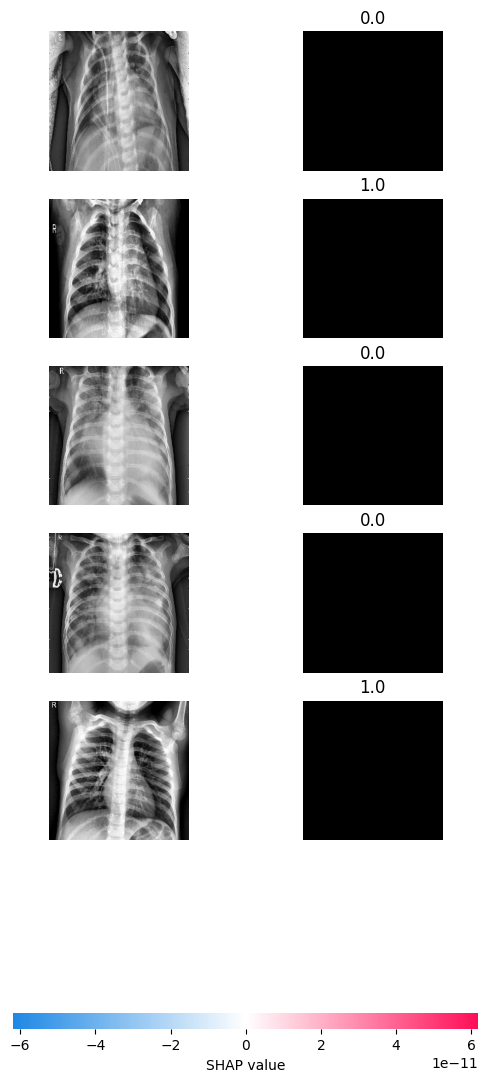

In [ ]:
shap.image_plot(shap_values, x_test[5:10] , labels =  y_test[5:10])

In [ ]:
print(predicted_classv[5:10])

[1 0 0 1 1]


In [ ]:
# print(shap_values[5:10])

In [ ]:
# positive_sample = x_train[0:10]
# positive_class = y_train[0:10]

# # Get negative sample from training set
# negative_sample = x_train[0:4]
# negative_class = y_train[0:4]

In [ ]:
# # Get Shapley values for the positive sample
# shap_values_positive = explainer.shap_values(positive_sample)

# # Get Shapley values for the negative sample
# shap_values_negative = explainer.shap_values(negative_sample)

# print(f"{shap_values_positive[1]}")
# # [0.0089429 , 0.01352552, 0.1930548 , 0.13567828, 0.03822685, 0.1438681 , 0.05501076, 0.02176474]

# print(f"{shap_values_negative[1]}")
# # [ 0.00137619,  0.00663525, -0.14600755, -0.11618931, -0.01479767, -0.07345027, -0.02249973, -0.00341222]


In [ ]:
# x = np.array(explainer.expected_value).reshape(-1,1)
# x = np.array(x).reshape(-1,1)

In [ ]:
# !pip install lime

In [ ]:
# import lime
# from lime import lime_image
# from lime import submodular_pick

# from skimage.segmentation import mark_boundaries

# explainer = lime_image.LimeImageExplainer()
# exp = explainer.explain_instance(x_train[0],
#                                  model.predict,
#                                  top_labels=5,
#                                  hide_color=0,
#                                  num_samples=1000)
# plt.imshow(exp.segments)
# plt.axis('off')
# plt.show()

In [ ]:
# def generate_prediction_sample(exp, exp_class, weight = 0.1, show_positive = True, hide_background = True):
#     '''
#     Method to display and highlight super-pixels used by the black-box model to make predictions
#     '''
#     image, mask = exp.get_image_and_mask(exp_class,
#                                          positive_only=show_positive,
#                                          num_features=6,
#                                          hide_rest=hide_background,
#                                          min_weight=weight
#                                         )
#     plt.imshow(mark_boundaries(image, mask))
#     plt.axis('off')
#     plt.show()
# generate_prediction_sample(exp, exp.top_labels[0], show_positive = True, hide_background = True)

In [ ]:
# generate_prediction_sample(exp, exp.top_labels[0], show_positive = True, hide_background = False)

In [ ]:
# generate_prediction_sample(exp, exp.top_labels[0], show_positive = False, hide_background = False)

In [ ]:
# def explanation_heatmap(exp, exp_class):
#     '''
#     Using heat-map to highlight the importance of each super-pixel for the model prediction
#     '''
#     dict_heatmap = dict(exp.local_exp[exp_class])
#     heatmap = np.vectorize(dict_heatmap.get)(exp.segments)
#     plt.imshow(heatmap, cmap = 'RdBu', vmin  = -heatmap.max(), vmax = heatmap.max())
#     plt.colorbar()
#     plt.show()

# explanation_heatmap(exp, exp.top_labels[0])

### Ensemble

In [ ]:
modele = keras.models.load_model('/content/drive/MyDrive/Explainable AI _ Research/ensemble.h5')

In [ ]:
# x_train, y_train = next(train_generator)
# x_test, y_test = next(test_generator)

In [ ]:
# x_train.shape

In [ ]:
# x_train = x_train.astype("float32")
# x_test = x_test.astype("float32")
# # y_train = y_train.reshape(49,)
# # y_test = y_test.reshape(49,)

In [ ]:
predictionse = modele.predict(test_generator)
predicted_classe = np.argmax(predictionse, axis=1)

20/20 [==============================] - 867s 43s/step


In [ ]:
# import shap

In [ ]:
print(tf. __version__)

2.15.0


In [ ]:
# select backgroud for shap
backgrounde = x_train[5:10]
# background = x_train
# DeepExplainer to explain predictions of the model
# shap.explainers.deep.deep_tf.op_handlers["AddV2"] = shap.explainers.deep.deep_tf.passthrough
explainere = shap.GradientExplainer(modele, backgrounde)

# compute shap values
shap_valuese = explainere.shap_values(x_test[5:10])

/usr/local/lib/python3.10/dist-packages/keras/src/backend.py:452: UserWarning: `tf.keras.backend.set_learning_phase` is deprecated and will be removed after 2020-10-11. To update it, simply pass a True/False value to the `training` argument of the `__call__` method of your layer or model.
  warnings.warn(


In [ ]:
shap.image_plot(shap_valuese, x_test[5:10] , labels =  y_test[5:10])

In [ ]:
predicted_classe[5:10]

In [ ]:
# positive_sample = x_train[0:10]
# positive_class = y_train[0:10]

# # Get negative sample from training set
# negative_sample = x_train[0:4]
# negative_class = y_train[0:4]

In [ ]:
# # Get Shapley values for the positive sample
# shap_values_positive = explainer.shap_values(positive_sample)

# # Get Shapley values for the negative sample
# shap_values_negative = explainer.shap_values(negative_sample)

# print(f"{shap_values_positive[1]}")
# # [0.0089429 , 0.01352552, 0.1930548 , 0.13567828, 0.03822685, 0.1438681 , 0.05501076, 0.02176474]

# print(f"{shap_values_negative[1]}")
# # [ 0.00137619,  0.00663525, -0.14600755, -0.11618931, -0.01479767, -0.07345027, -0.02249973, -0.00341222]


In [ ]:
# x = np.array(explainer.expected_value).reshape(-1,1)
# x = np.array(x).reshape(-1,1)

In [ ]:
# !pip install lime

In [ ]:
# import lime
# from lime import lime_image
# from lime import submodular_pick

# from skimage.segmentation import mark_boundaries

# explainer = lime_image.LimeImageExplainer()
# exp = explainer.explain_instance(x_train[0],
#                                  model.predict,
#                                  top_labels=5,
#                                  hide_color=0,
#                                  num_samples=1000)
# plt.imshow(exp.segments)
# plt.axis('off')
# plt.show()

In [ ]:
# def generate_prediction_sample(exp, exp_class, weight = 0.1, show_positive = True, hide_background = True):
#     '''
#     Method to display and highlight super-pixels used by the black-box model to make predictions
#     '''
#     image, mask = exp.get_image_and_mask(exp_class,
#                                          positive_only=show_positive,
#                                          num_features=6,
#                                          hide_rest=hide_background,
#                                          min_weight=weight
#                                         )
#     plt.imshow(mark_boundaries(image, mask))
#     plt.axis('off')
#     plt.show()
# generate_prediction_sample(exp, exp.top_labels[0], show_positive = True, hide_background = True)

In [ ]:
# generate_prediction_sample(exp, exp.top_labels[0], show_positive = True, hide_background = False)

In [ ]:
# generate_prediction_sample(exp, exp.top_labels[0], show_positive = False, hide_background = False)

In [ ]:
# def explanation_heatmap(exp, exp_class):
#     '''
#     Using heat-map to highlight the importance of each super-pixel for the model prediction
#     '''
#     dict_heatmap = dict(exp.local_exp[exp_class])
#     heatmap = np.vectorize(dict_heatmap.get)(exp.segments)
#     plt.imshow(heatmap, cmap = 'RdBu', vmin  = -heatmap.max(), vmax = heatmap.max())
#     plt.colorbar()
#     plt.show()

# explanation_heatmap(exp, exp.top_labels[0])

### DenseNet

In [ ]:
modeld = keras.models.load_model('/content/drive/MyDrive/Explainable AI _ Research/DenseNetData2.h5')

In [ ]:
# x_train, y_train = next(train_generator)
# x_test, y_test = next(test_generator)

In [ ]:
# x_train.shape

In [ ]:
# x_train = x_train.astype("float32")
# x_test = x_test.astype("float32")
# # y_train = y_train.reshape(49,)
# # y_test = y_test.reshape(49,)

In [ ]:
predictionsd = modeld.predict(test_generator)
predicted_classd = np.argmax(predictionsd, axis=1)

In [ ]:
# import shap

In [ ]:
# print(tf. __version__)

In [ ]:
# select backgroud for shap
backgroundd = x_train[5:10]
# background = x_train
# DeepExplainer to explain predictions of the model
# shap.explainers.deep.deep_tf.op_handlers["AddV2"] = shap.explainers.deep.deep_tf.passthrough
explainerd = shap.GradientExplainer(modeld, backgroundd)

# compute shap values
shap_valuesd = explainerd.shap_values(x_test[5:10])

In [ ]:
shap.image_plot(shap_valuesd, x_test[5:10] , labels =  y_test[5:10])

In [ ]:
predicted_classd[5:10]

# Metrics

In [ ]:
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.layers.experimental import preprocessing
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, cohen_kappa_score, roc_auc_score, confusion_matrix
from sklearn.metrics import classification_report
from keras.layers import Dense, Dropout, Activation, Flatten, BatchNormalization, Conv2D, MaxPool2D, MaxPooling2D
from tensorflow.keras.callbacks import ReduceLROnPlateau, ModelCheckpoint, EarlyStopping
from tensorflow.keras import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D


In [ ]:
def learning_curve(model_fit, key='accuracy', ylim=(0, 1.01)):
    plt.figure(figsize=(12,6))
    plt.plot(model_fit.history[key])
    plt.plot(model_fit.history['val_' + key])
    plt.title('Learning Curve')
    plt.ylabel(key.title())
    plt.xlabel('Epoch')
    plt.ylim(ylim)
    plt.legend(['train', 'val'], loc='best')
    plt.show()


In [ ]:
learning_curve(history,'loss', ylim=(0,1))
learning_curve(history, 'accuracy', ylim=(0,1))

In [ ]:
test_loss, test_acc = model.evaluate(test_generator, steps=len(test_generator), verbose=1)
print('Loss: %.3f' % (test_loss * 100.0))
print('Accuracy: %.3f' % (test_acc * 100.0))

In [ ]:
v_predictions = np.argmax(model.predict(test_generator),axis=1)
v_labels = test_generator.classes
v_predictions , v_labels

In [ ]:
def fbeta(y_true, y_pred, threshold_shift=0):
    beta_squared = 4

    y_pred = K.clip(y_pred, 0, 1)

    y_pred_bin = K.round(y_pred + threshold_shift)

    tp = K.sum(K.round(y_true * y_pred_bin)) + K.epsilon()
    fp = K.sum(K.round(K.clip(y_pred_bin - y_true, 0, 1)))
    fn = K.sum(K.round(K.clip(y_true - y_pred, 0, 1)))

    precision = tp / (tp + fp)
    recall = tp / (tp + fn)

    return (beta_squared + 1) * (precision * recall) / (beta_squared * precision + recall + K.epsilon())

In [ ]:
def confusion_matrix_plot(matrix):
    plt.figure(figsize=(12,10))
    cmap = "YlGnBu"
    ax= plt.subplot()
    sns.heatmap(matrix, annot=True, fmt='g', ax=ax, cmap=cmap);  #annot=True to annotate cells, ftm='g' to disable scientific notation
    # plt.savefig('/kaggle/working/img1.png')
    # labels, title and ticks
    ax.set_xlabel('Predicted labels');
    ax.set_ylabel('True labels');
    ax.set_title('Confusion Matrix');
    ax.xaxis.set_ticklabels(classes);
    ax.yaxis.set_ticklabels(classes[::-1]);
    plt.show()

In [ ]:
def cal_score(model, key, predictions, labels):
    matrix = confusion_matrix(predictions, labels)
    print(matrix)
    print('\n')

    f1 = f1_score(predictions, labels, average='weighted')
    print(f'F1 Score: {f1}')
    print('\n')

    print(classification_report(predictions, labels, target_names=classes))

    if key==1:
        confusion_matrix_plot(matrix)

In [ ]:
cal_score(model, 1, v_predictions, v_labels)

In [ ]:
import os
test_path = '/content/drive/MyDrive/Explainable AI _ Research/chest_xray/test/'
classes = []
for i in os.listdir(test_path):
    classes+=[i]

classes = classes[1:]

In [ ]:
test_loss, test_acc = modeld.evaluate(test_generator, steps=len(test_generator), verbose=1)
print('Loss: %.3f' % (test_loss * 100.0))
print('Accuracy: %.3f' % (test_acc * 100.0))

In [ ]:
d_predictions = np.argmax(modeld.predict(test_generator),axis=1)
d_labels = test_generator.classes
d_predictions , d_labels

In [ ]:
cal_score(modeld, 1, d_predictions, d_labels)

In [ ]:
test_loss, test_acc = modele.evaluate(test_generator, steps=len(test_generator), verbose=1)
print('Loss: %.3f' % (test_loss * 100.0))
print('Accuracy: %.3f' % (test_acc * 100.0))

In [ ]:
e_predictions = np.argmax(modele.predict(test_generator),axis=1)
e_labels = test_generator.classes
e_predictions , e_labels

In [ ]:
cal_score(modele, 1, e_predictions, e_labels)